In [ ]:
!pip install wandb
GOOGLE_COLAB = True

if GOOGLE_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  path = '/content/drive/MyDrive/Colab Notebooks/TIGER plots'

else:
  path = ''

###################################
import matplotlib.pyplot as plt
import os
import pandas as pd
import itertools
os.chdir(path)

In [ ]:
def get_color_cycle(algorithms):
  """
  Creates a circular buffer of colors for plotting multiple algorithms.

  Args:
    algorithms: A list of algorithm names.

  Returns:
    A dictionary mapping each algorithm to a unique color.
  """
  colors = itertools.cycle(plt.cm.get_cmap('tab10').colors)  # You can choose a different colormap
  color_map = {}
  for algorithm in algorithms:
    color_map[algorithm] = next(colors)
  return color_map



def add_ema_columns(df, alpha=0.5, adjust=True):
  """
  Adds EMA columns for columns ending with "_reward" or "_budget".

  Args:
    df: The pandas DataFrame.
    alpha: The smoothing factor for the EMA calculation (default: 0.5).

  Returns:
    The DataFrame with added EMA columns.
  """
  for column in df.columns:
    if column.endswith("_reward") or column.endswith("_budget"):
      new_column_name = column + "_ema"
      df[new_column_name] = df[column].ewm(alpha=alpha, adjust=adjust).mean()
  return df


def add_ra_columns(df, num_avg_samples=10):
  """
  Adds Running AVG columns for columns ending with "_reward" or "_budget".

  Args:
    df: The pandas DataFrame.
    num_avg_samples: The number of samples to consider for the moving average.

  Returns:
    The DataFrame with added EMA columns.
  """
  for column in df.columns:
    if column.endswith("_reward") or column.endswith("_budget"):
      print('creating running average of column', column)
      new_column_name = column + "_ra"
      df[new_column_name] = df[column].rolling(window=num_avg_samples, min_periods=1).mean()
  return df


# Create a custom handler for vertical lines in legend
class VerticalLineHandler:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width = handlebox.width
        height = handlebox.height
        # Create a vertical line in the center of the box
        line = plt.Line2D([x0 + width/2, x0 + width/2],
                         [y0, y0 + height],
                         color=orig_handle.get_color(),
                         linestyle=orig_handle.get_linestyle())
        handlebox.add_artist(line)
        return line


# formatting stuff:
title_font_dict = {'weight': 'bold', 'size': 30}
axis_font_dict = {'weight': 'bold', 'size': 18}
legend_font_dict = {'weight': 'bold', 'size': 16}

In [ ]:
omni = pd.read_csv('omni.csv').head(2000)


columns_to_drop = [col for col in omni.columns if col.endswith('MIN') \
                       or col.endswith('MAX') ]

omni.drop(columns=columns_to_drop, inplace=True)

new_columns = []
for col in omni.columns:
  new_col = col.replace(" - AGENT_budget", "_budget")
  new_col = new_col.replace(" - Epistemic Actions taken", "_ea")
  new_col = new_col.replace(" - AGENT_reward", "_reward")
  new_columns.append(new_col)

omni.columns = new_columns
omni.fillna(0, inplace=True)

algorithm_suffixes = set()
for col in omni.columns:
  if '_budget' in col:
    algorithm_suffixes.add(col.split('_budget')[0])

# prompt: the omni dataframe contains 3 times n cols, where n is the number of algoritms used. the algorithms are suffixes in the col names, which follow the template [SUFFIX]_budget, [SUFFIX]_ea and [SUFFIX]_reward.
# create a new column for each algorithm, called [SUFFIX]_es (which stands for episode starts). The colum should be all zeros, except when the [SUFFIX_budget] column gets lower than -10 or greater that 25

for suffix in algorithm_suffixes:
  omni[f'{suffix}_es'] = 0
  omni.loc[(omni[f'{suffix}_budget'] < -10) | (omni[f'{suffix}_budget'] > 25), f'{suffix}_es'] = 1


omni = add_ema_columns(omni, alpha=0.67, adjust=False)
omni = add_ra_columns(omni, num_avg_samples=50)

algorithms = ['DDQN', 'DQN']

# Get the color cycle
color_map = get_color_cycle(algorithms)


creating running average of column DDQN_budget
creating running average of column DDQN_reward
creating running average of column DQN_budget
creating running average of column DQN_reward


<ipython-input-95-5c62fe842b94>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = itertools.cycle(plt.cm.get_cmap('tab10').colors)  # You can choose a different colormap


now plotting: DDQN_reward_ra
now plotting: DQN_reward_ra


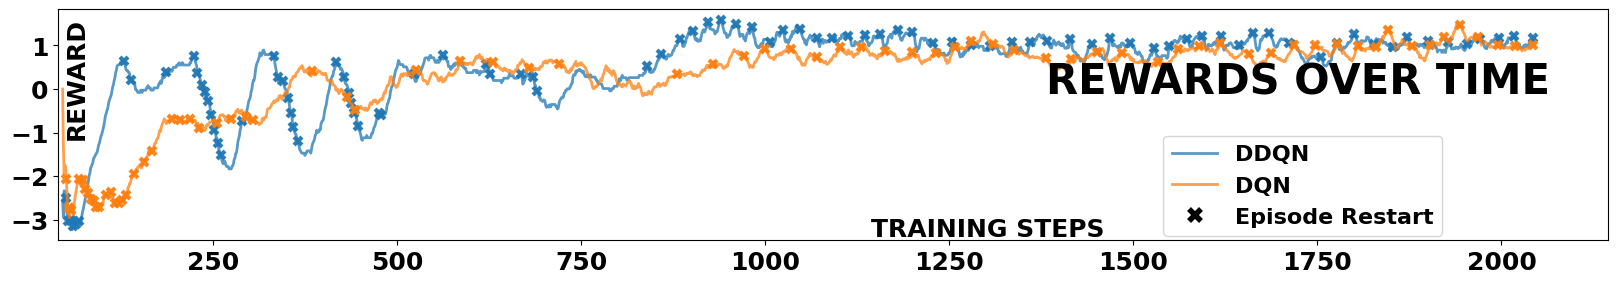

In [ ]:


# Create the plot with specified dimensions
fig, ax = plt.subplots(figsize=(20, 3))  # Adjust width and height as needed

# Loop through each algorithm and plot the data
for algorithm in algorithms:
    # Plot the "_reward" column as a line
    print(f'now plotting: {algorithm}_reward_ra')
    ax.plot(omni['Step'], omni[f'{algorithm}_reward_ra'], label=f'{algorithm}', alpha=0.75, color=color_map[algorithm], lw=2)

    # Plot crosses where the "_es" column has a 1
    es_indices = omni.index[omni[f'{algorithm}_es'] == 1].tolist()
    es_rewards = omni.loc[es_indices, f'{algorithm}_reward_ra'].tolist()
    ax.plot(omni.loc[es_indices,'Step'], es_rewards, 'x', markersize=6, markeredgewidth=3, alpha=0.95, color=color_map[algorithm])

ax.plot([], [], 'x', markersize=8, markeredgewidth=4, color='black', label='Episode Restart')

# Customize the plot
ax.set_xlim(left=40)  # You can replace 0 with your desired xmin value

ax.set_xlabel('TRAINING STEPS', fontdict=axis_font_dict)
ax.set_ylabel('REWARD', fontdict=axis_font_dict)
ax.set_title('REWARDS OVER TIME', fontdict=title_font_dict, y=0.6, x=0.8)
ax.legend(prop=legend_font_dict, bbox_to_anchor=(0.9, 0.5))

ax.xaxis.set_label_coords(0.6, 0.1)  # Moves xlabel right and down
ax.yaxis.set_label_coords(0.02, 0.7)  # Moves ylabel left

# Increase font size of xticks and yticks
plt.xticks(fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')

# Display the plot
plt.show()

In [ ]:
omni_slice_1 = omni.iloc[25:90]
omni_slice_2 = omni.iloc[800:900]
omni_slice = pd.concat([omni_slice_1, omni_slice_2])

<ipython-input-99-97cbdb520773>:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontsize=18, weight='bold', rotation=45)
<ipython-input-99-97cbdb520773>:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18, weight='bold')
<ipython-input-99-97cbdb520773>:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontsize=18, weight='bold', rotation=45)
<ipython-input-99-97cbdb520773>:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18, weight='bold')


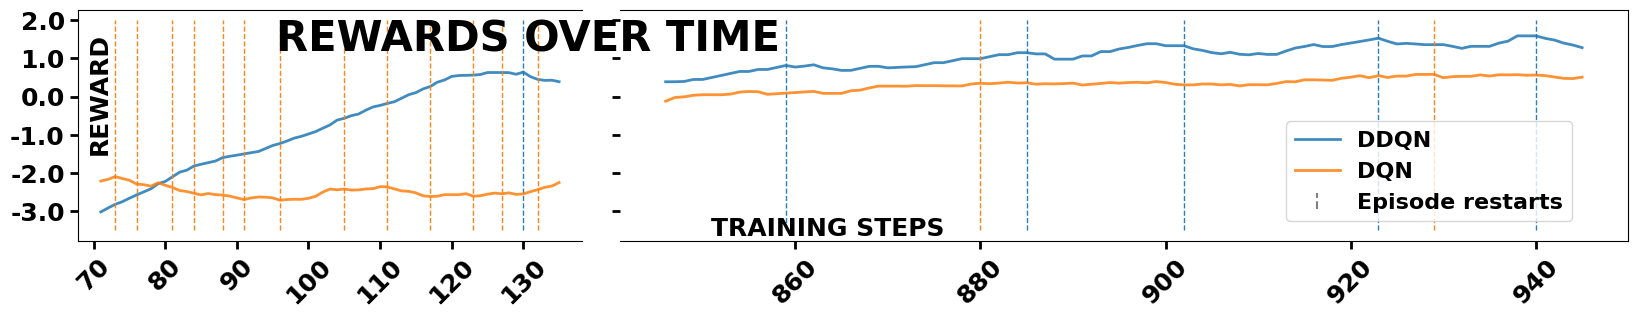

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_with_break(omni_slice_1, omni_slice_2, algorithms, color_map,
                   axis_font_dict, title_font_dict, legend_font_dict):

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, width_ratios=[1, 2], figsize=(20, 3))
    fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

    # Function to plot data on a given axis
    def plot_segment(ax, data, algorithms):
        for algorithm in algorithms:
            # Plot the budget line
            ax.plot(data['Step'], data[f'{algorithm}_reward_ra'],
                   label=f'{algorithm}', alpha=0.85,
                   color=color_map[algorithm], lw=2)
            """
            # Plot epistemic actions
            ea_indices = data.index[data[f'{algorithm}_ea'] == 1].tolist()
            es_rewards = data.loc[ea_indices, f'{algorithm}_reward_ra'].tolist()
            ax.plot(data.loc[ea_indices,'Step'], es_rewards, 'x',
                   markersize=8, markeredgewidth=2, alpha=1,
                   color=color_map[algorithm])
            """
            # Plot episode restarts as vertical lines
            es_indices = data.index[data[f'{algorithm}_es'] == 1].tolist()
            for idx in es_indices:
                # Get the x and y coordinates
                x = data.loc[idx, 'Step']
                y = data.loc[idx, f'{algorithm}_reward_ra']
                ax.vlines(x=x, ymin=-3.5, ymax=2, color=color_map[algorithm],  linestyle='--',
                        alpha=0.95, linewidth=1, linestyles='solid')


    # Plot early steps on left subplot
    plot_segment(ax1, omni_slice_1, algorithms)
    # Plot later steps on right subplot
    plot_segment(ax2, omni_slice_2, algorithms)

    # Add diagonal lines to indicate break
    d = .015  # Size of diagonal lines
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, **axis_font_dict)
    ax1.spines['right'].set_visible(False)

    kwargs.update(transform=ax2.transAxes, **axis_font_dict)
    ax2.spines['left'].set_visible(False)


    # Customize appearance
    for ax in [ax1, ax2]:

        ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontsize=18, weight='bold', rotation=45)
        ax.set_yticklabels(ax.get_yticks(), fontsize=18, weight='bold')
        ax.tick_params(width=2, length=6)



    # Add labels and title with explicit font settings
    xlabel = fig.supxlabel('TRAINING STEPS', y=0.11)
    xlabel.set_fontsize(axis_font_dict['size'])
    xlabel.set_fontweight(axis_font_dict['weight'])

    ylabel = fig.supylabel('REWARD', x=0.13, y=.6)
    ylabel.set_fontsize(axis_font_dict['size'])
    ylabel.set_fontweight(axis_font_dict['weight'])

    title = fig.suptitle('REWARDS OVER TIME', y=0.85, x=0.35)
    title.set_fontsize(30)
    title.set_fontweight(title_font_dict['weight'])

    # Add single legend for both subplots
    lines1, labels1 = ax2.get_legend_handles_labels()
    dummy_line = plt.Line2D([], [], marker='x', color='gray',
                           linestyle='None', markersize=8, markeredgewidth=2,
                           label='Epistemic Actions')
    dummy_line2 = plt.Line2D([], [], linestyle='--', color='gray',
                           label='Episode Restart')
    dummy_line3 = plt.Line2D([], [], linestyle='--', lw=1, alpha=0.5, color='red',
                           label='Max. Budget')
    dummy_line4 = plt.Line2D([], [], linestyle='--', lw=1, alpha=0.5, color='green',
                           label='Min. Budget')



    ax2.legend([*lines1,  dummy_line2], [*labels1, 'Episode restarts'],
               prop=legend_font_dict, loc='center left', bbox_to_anchor=(0.65, 0.3),
               handler_map={dummy_line2: VerticalLineHandler()})

    return fig, (ax1, ax2), lines1, labels1

# Use the function
fig, (ax1, ax2), lines1, labels1 = plot_with_break(omni_slice_1, omni_slice_2, algorithms, color_map,
                                 axis_font_dict, title_font_dict, legend_font_dict)
plt.show()

<ipython-input-100-563d33435591>:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontsize=18, weight='bold', rotation=0)
<ipython-input-100-563d33435591>:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18, weight='bold')
<ipython-input-100-563d33435591>:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontsize=18, weight='bold', rotation=0)
<ipython-input-100-563d33435591>:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18, weight='bold')


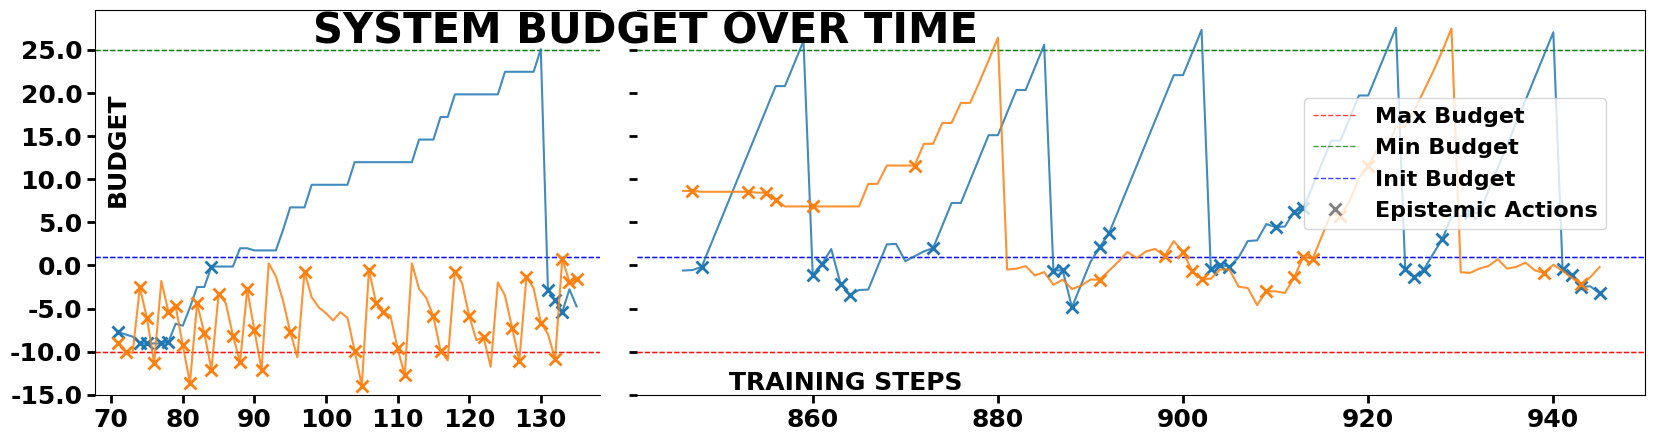

In [ ]:
def plot_with_break(omni_slice_1, omni_slice_2, algorithms, color_map,
                   axis_font_dict, title_font_dict, legend_font_dict):

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, width_ratios=[1, 2], figsize=(20, 5))
    fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

    # Function to plot data on a given axis
    def plot_segment(ax, data, algorithms):
        for algorithm in algorithms:
            # Plot the budget line
            ax.plot(data['Step'], data[f'{algorithm}_budget'],
                   label=f'{algorithm}', alpha=0.85,
                   color=color_map[algorithm], lw=1.5)

            # Plot epistemic actions
            es_indices = data.index[data[f'{algorithm}_ea'] == 1].tolist()
            es_rewards = data.loc[es_indices, f'{algorithm}_budget'].tolist()
            ax.plot(data.loc[es_indices,'Step'], es_rewards, 'x',
                   markersize=8, markeredgewidth=2, alpha=1,
                   color=color_map[algorithm])
            ax.axhline(y=-10, color='red', linestyle='--', lw=1, alpha=0.75, zorder=0, label='Max Budget')  # Add the line at y=-10
            ax.axhline(y=25, color='green', linestyle='--', lw=1, alpha=0.75, zorder=0, label='Min Budget')   # Add the line at y=25
            ax.axhline(y=1, color='blue', linestyle='--', lw=1, alpha=0.75, zorder=0, label='Init Budget')   # Add the line at y=25

    # Plot early steps on left subplot
    plot_segment(ax1, omni_slice_1, algorithms)
    # Plot later steps on right subplot
    plot_segment(ax2, omni_slice_2, algorithms)

    # Add diagonal lines to indicate break
    d = .015  # Size of diagonal lines
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, **axis_font_dict)
    ax1.spines['right'].set_visible(False)

    kwargs.update(transform=ax2.transAxes, **axis_font_dict)
    ax2.spines['left'].set_visible(False)


    # Customize appearance
    for ax in [ax1, ax2]:

        ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontsize=18, weight='bold', rotation=0)
        ax.set_yticklabels(ax.get_yticks(), fontsize=18, weight='bold')
        ax.tick_params(width=2, length=6)
        ax.set_ylim(bottom=-15)  # Start y-axis from 0



    # Add labels and title with explicit font settings
    xlabel = fig.supxlabel('TRAINING STEPS', y=0.11)
    xlabel.set_fontsize(axis_font_dict['size'])
    xlabel.set_fontweight(axis_font_dict['weight'])

    ylabel = fig.supylabel('BUDGET', x=0.13, y=.6)
    ylabel.set_fontsize(axis_font_dict['size'])
    ylabel.set_fontweight(axis_font_dict['weight'])

    title = fig.suptitle('SYSTEM BUDGET OVER TIME', y=0.88, x=0.4)
    title.set_fontsize(30)
    title.set_fontweight(title_font_dict['weight'])

    # Add single legend for both subplots
    lines1, labels1 = ax2.get_legend_handles_labels()
    dummy_line = plt.Line2D([], [], marker='x', color='gray',
                           linestyle='None', markersize=8, markeredgewidth=2,
                           label='Epistemic Actions')

    # we do not take the last two rows of the legend because they repeat
    # the Max Budget/Min Budget legend:
    lines1 = [lines1[1], lines1[2], lines1[3], dummy_line]
    labels1 = [labels1[1], labels1[2], labels1[3], 'Epistemic Actions']

    ax2.legend([*lines1], [*labels1],
               prop=legend_font_dict, loc='center left', bbox_to_anchor=(0.65, 0.6))

    return fig, (ax1, ax2), lines1, labels1

# Use the function
fig, (ax1, ax2), lines1, labels1 = plot_with_break(omni_slice_1, omni_slice_2, algorithms, color_map,
                                 axis_font_dict, title_font_dict, legend_font_dict)
plt.show()

# New metrics:

In [ ]:
def prepend_to_columns(df, string):
  """Prepends a string followed by an underscore to all column names in a DataFrame.

  Args:
    df: The pandas DataFrame to modify.
    string: The string to prepend to each column name.

  Returns:
    A new DataFrame with modified column names.
  """
  new_columns = [(string + '_' + col if col != 'step' else 'step') for col in df.columns ]

  return df.rename(columns=dict(zip(df.columns, new_columns)))


def fill_ending_episode(df):
    # Get the index positions of all '1's
    ones_indices = df.index[df['ending_episode'] == 1].tolist()

    # Initialize a list to hold the counts
    counts = []
    prev_one_index = 0

    for i in range(len(df)):
        # If current index is in ones_indices, append 0 (or keep it as is)
        if i in ones_indices:
            if len(counts) > 0:
                counts.append(counts[-1])
            else:
                counts.append(0)
            prev_one_index = i
        else:
            # Find the next '1' index
            next_one_index = next((index for index in ones_indices if index > i), None)
            if next_one_index is not None:
                counts.append(next_one_index - prev_one_index)
            else:
                counts.append(0)  # No more '1's found

    df['episode_length'] = counts
    return df


In [ ]:
import wandb
api = wandb.Api()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [ ]:
ddqn_run_id = "jfcevallos/TIGER/g93m4pno"
dqn_run_id = "jfcevallos/TIGER/2yc8533n"
ddqn_run = api.run(ddqn_run_id).scan_history()
dqn_run = api.run(dqn_run_id).scan_history()

In [ ]:
ddqn_dataframe = pd.DataFrame(
      [
        {
              "step" : row["_step"],
              "classification_reward": row["classification_reward"],
              "known_traffic_action": row["known traffic action"],
              "AGENT_reward": row["AGENT_reward"],
              "AGENT_budget"  : row["AGENT_budget"]
        }
          for row in ddqn_run
      ]
    )

dqn_dataframe = pd.DataFrame(
      [
        {
              "step" : row["_step"],
              "classification_reward": row["classification_reward"],
              "known_traffic_action": row["known traffic action"],
              "AGENT_reward": row["AGENT_reward"],
              "AGENT_budget"  : row["AGENT_budget"]
        }
          for row in dqn_run
      ]
    )


In [ ]:
ddqn_dataframe['ending_episode'] = 0
ddqn_dataframe.loc[(ddqn_dataframe['AGENT_budget'] > 25) | (ddqn_dataframe['AGENT_budget'] < -10), 'ending_episode'] = 1
ddqn_dataframe = fill_ending_episode(ddqn_dataframe)
# compute the ratio between the running average period and the episode length
ddqn_dataframe['episode_length'] /= 50
ddqn_dataframe['episode_length'] = ddqn_dataframe['episode_length'].rolling(window=50, min_periods=1).mean()


dqn_dataframe['ending_episode'] = 0
dqn_dataframe.loc[(dqn_dataframe['AGENT_budget'] > 25) | (dqn_dataframe['AGENT_budget'] < -10), 'ending_episode'] = 1
dqn_dataframe = fill_ending_episode(dqn_dataframe)
dqn_dataframe['episode_length'] /= 50
dqn_dataframe['episode_length'] = dqn_dataframe['episode_length'].rolling(window=50, min_periods=1).mean()

"""
max_episode_len = max(ddqn_dataframe['episode_length'].max(), dqn_dataframe['episode_length'].max())
ddqn_dataframe['episode_length'] /= max_episode_len
dqn_dataframe['episode_length'] /= max_episode_len
"""

ddqn_dataframe['clustering_reward'] = ddqn_dataframe['classification_reward'] - ddqn_dataframe['AGENT_reward']
dqn_dataframe['clustering_reward'] = dqn_dataframe['classification_reward'] - dqn_dataframe['AGENT_reward']

ddqn_dataframe['classification_reward_ra'] = ddqn_dataframe['classification_reward'].rolling(window=50, min_periods=1).mean()
dqn_dataframe['classification_reward_ra'] = dqn_dataframe['classification_reward'].rolling(window=50, min_periods=1).mean()
max_classif_reward = max(ddqn_dataframe['classification_reward_ra'].max(), dqn_dataframe['classification_reward_ra'].max())
ddqn_dataframe['classification_reward_ra'] /= max_classif_reward
dqn_dataframe['classification_reward_ra'] /= max_classif_reward


ddqn_dataframe['clustering_reward'] = ddqn_dataframe['clustering_reward'].rolling(window=50, min_periods=1).mean()
dqn_dataframe['clustering_reward'] = dqn_dataframe['clustering_reward'].rolling(window=50, min_periods=1).mean()
max_agent_clustering_reward = max(ddqn_dataframe['clustering_reward'].max(), dqn_dataframe['clustering_reward'].max())
min_agent_clustering_reward = min(ddqn_dataframe['clustering_reward'].min(), dqn_dataframe['clustering_reward'].min())



ddqn_dataframe['AGENT_reward'] = ddqn_dataframe['AGENT_reward'].rolling(window=50, min_periods=1).mean()
dqn_dataframe['AGENT_reward'] = dqn_dataframe['AGENT_reward'].rolling(window=50, min_periods=1).mean()
max_agent_reward = max(ddqn_dataframe['AGENT_reward'].max(), dqn_dataframe['AGENT_reward'].max())
min_agent_reward = min(ddqn_dataframe['AGENT_reward'].min(), dqn_dataframe['AGENT_reward'].min())
ddqn_dataframe['AGENT_reward'] = (ddqn_dataframe['AGENT_reward'] - min_agent_reward) / (max_agent_reward - min_agent_reward)
dqn_dataframe['AGENT_reward'] = (dqn_dataframe['AGENT_reward'] - min_agent_reward) / (max_agent_reward - min_agent_reward)


ddqn_dataframe['clustering_reward'] = (ddqn_dataframe['clustering_reward'] - min_agent_clustering_reward) / (max_agent_clustering_reward - min_agent_clustering_reward)
dqn_dataframe['clustering_reward'] = (dqn_dataframe['clustering_reward'] - min_agent_clustering_reward) / (max_agent_clustering_reward - min_agent_clustering_reward)

ddqn_dataframe['pragmatic_action_rate'] = (ddqn_dataframe['known_traffic_action'] == 0).astype(int)
dqn_dataframe['pragmatic_action_rate'] = (dqn_dataframe['known_traffic_action'] == 0).astype(int)

ddqn_dataframe.drop(columns=['known_traffic_action'], inplace=True)
dqn_dataframe.drop(columns=['known_traffic_action'], inplace=True)

ddqn_dataframe['pragmatic_action_rate'] = ddqn_dataframe['pragmatic_action_rate'].rolling(window=50, min_periods=1).mean()
dqn_dataframe['pragmatic_action_rate'] = dqn_dataframe['pragmatic_action_rate'].rolling(window=50, min_periods=1).mean()

In [ ]:
ddqn_dataframe = prepend_to_columns(ddqn_dataframe, 'DDQN')
dqn_dataframe = prepend_to_columns(dqn_dataframe, 'DQN')

merged_df = pd.merge(ddqn_dataframe, dqn_dataframe, on='step')
merged_df

,step,DDQN_classification_reward,DDQN_AGENT_reward,DDQN_AGENT_budget,DDQN_ending_episode,DDQN_episode_length,DDQN_clustering_reward,DDQN_classification_reward_ra,DDQN_pragmatic_action_rate,DQN_classification_reward,DQN_AGENT_reward,DQN_AGENT_budget,DQN_ending_episode,DQN_episode_length,DQN_clustering_reward,DQN_classification_reward_ra,DQN_pragmatic_action_rate
0,47,0.00,0.070208,-4.870000,0,0.080000,0.753853,0.000000,0.000000,0.00,0.149321,-1.550000,0,0.0800,0.654966,0.000000,0.000000
1,48,1.88,0.193159,-6.010000,0,0.080000,0.761130,0.293741,0.333333,0.00,0.070208,-4.870000,0,0.0800,0.753853,0.000000,0.000000
2,49,1.88,0.191960,-8.369999,0,0.080000,0.843108,0.440611,0.500000,2.06,0.196583,-5.960000,0,0.0800,0.772260,0.321865,0.333333
3,50,0.00,0.161650,-11.449999,1,0.080000,0.832705,0.352489,0.400000,2.19,0.210454,-8.010000,0,0.0800,0.851455,0.498031,0.500000
4,51,1.30,0.139047,-2.150000,0,0.076667,0.884418,0.395300,0.500000,0.00,0.163705,-11.400000,1,0.0800,0.855308,0.398425,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2072,2119,2.55,0.929888,11.229998,0,0.411200,0.183596,0.920315,0.880000,0.00,0.889324,1.679999,0,0.3316,0.207380,0.871192,0.940000
2073,2120,2.55,0.934244,13.849998,0,0.410800,0.180873,0.925284,0.880000,2.55,0.893681,4.299999,0,0.3208,0.204658,0.876160,0.940000
2074,2121,2.55,0.940696,16.469997,0,0.410400,0.175531,0.930252,0.880000,2.55,0.902804,6.919999,0,0.3132,0.198699,0.886097,0.940000
2075,2122,2.55,0.957998,19.089997,0,0.410000,0.155753,0.933627,0.880000,2.55,0.911928,9.539999,0,0.3056,0.192740,0.896035,0.940000


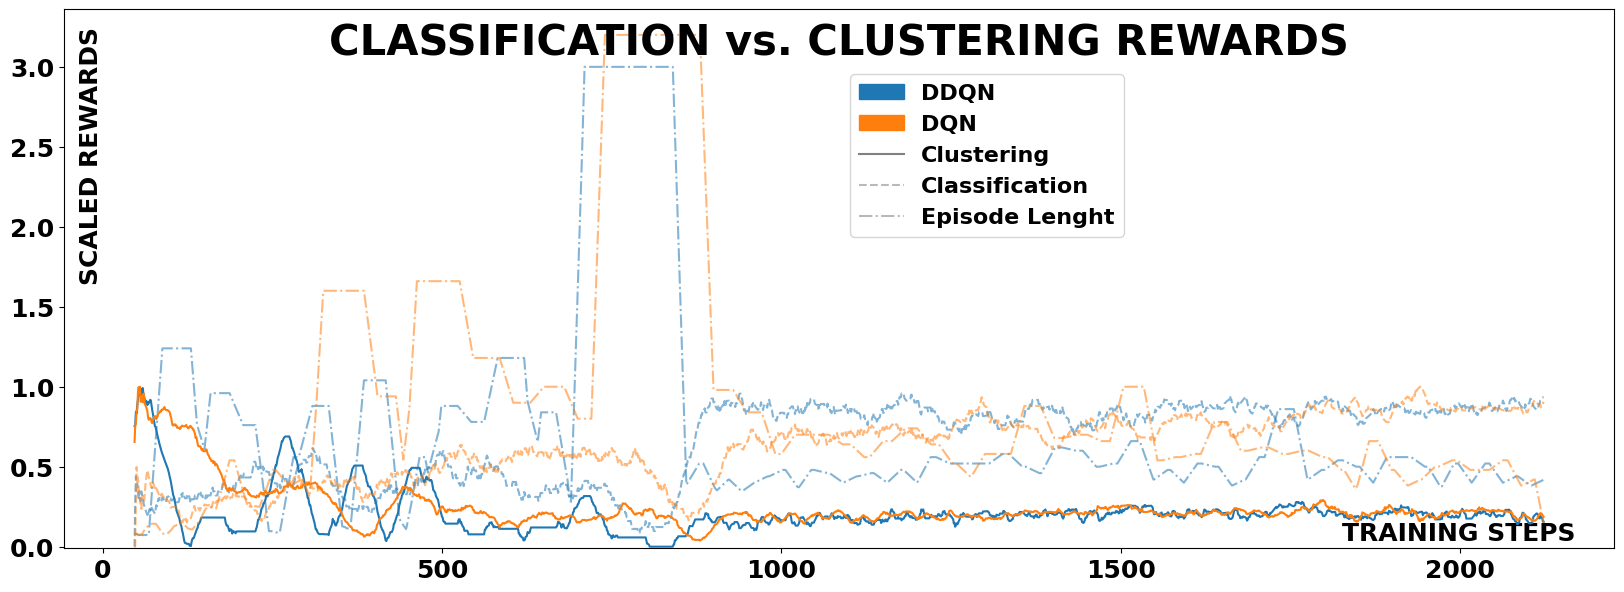

In [ ]:
import matplotlib.patches as mpatches


algorithms = ['DDQN', 'DQN']

data = merged_df

fig, ax = plt.subplots(figsize=(20, 7))

handles = []

for algorithm in algorithms:

    ax.plot(data['step'], data[f'{algorithm}_clustering_reward'],
            label=f'{algorithm} Clustering Rewards', alpha=1,
            color=color_map[algorithm], lw=1.5)
    ax.plot(data['step'], data[f'{algorithm}_classification_reward_ra'],
            label=f'{algorithm} Classification Rewards', linestyle='--', alpha=0.55,
            color=color_map[algorithm], lw=1.5)
    ax.plot(data['step'], data[f'{algorithm}_episode_length'],
            label=f'{algorithm} Episode length', linestyle='-.', alpha=0.55,
            color=color_map[algorithm], lw=1.5)



    # Create a single gray patch for each algorithm
    algo_patch = mpatches.Patch(color=color_map[algorithm], label=algorithm)
    handles.append(algo_patch)


dummy_clustering_rewards_line = plt.Line2D([], [], color='gray',
                          alpha=1,
                           label='Clustering Rewards')

dummy_classification_rewards_line = plt.Line2D([], [], linestyle='--', color='gray',
                          alpha=0.55,
                           label='Classification Rewards')

dummy_episode_length_line = plt.Line2D([], [], linestyle='-.', color='gray',
                          alpha=0.55,
                           label='Mean Episode length')



# Increase font size of xticks and yticks
plt.xticks(fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')

ax.set_ylim(bottom=-0.01)
# ax.set_xlim(right=1140)


ax.set_title('CLASSIFICATION vs. CLUSTERING REWARDS', fontdict=title_font_dict, y=0.90)

ax.set_xlabel('TRAINING STEPS', fontdict=axis_font_dict)
ax.xaxis.set_label_coords(0.9, 0.05)

ax.set_ylabel('SCALED REWARDS', fontdict=axis_font_dict)
ax.yaxis.set_label_coords(0.025, 0.73)





plt.legend(
    handles + [dummy_clustering_rewards_line, dummy_classification_rewards_line, dummy_episode_length_line] ,
    [handle._label for handle in handles] + ['Clustering', 'Classification', 'Episode Lenght'],
    prop=legend_font_dict, bbox_to_anchor=(0.5, 0.9))



plt.show()

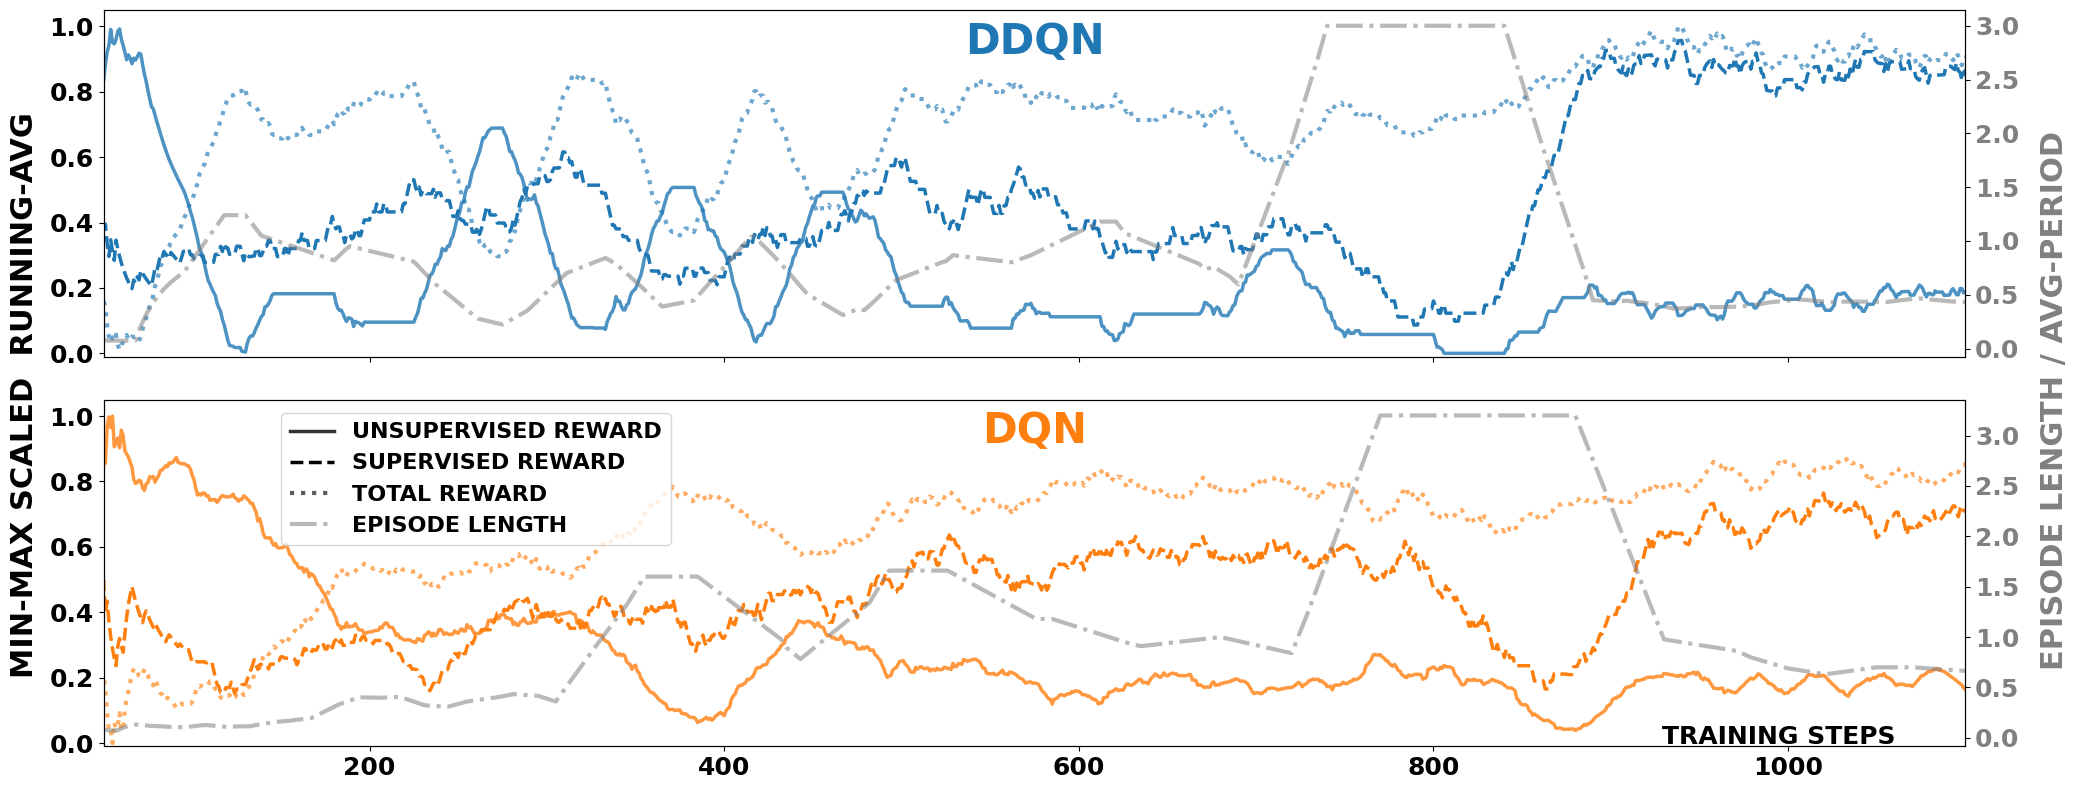

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define your algorithms and data
algorithms = ['DDQN', 'DQN']
data = merged_df

# Create a figure with two subplots (one above the other)
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 8), sharex=True)


# Loop through each algorithm and plot on the respective axis
for i, algorithm in enumerate(algorithms):
    ax = axs[i]  # Select the current axis

    # Plot Clustering Rewards
    ax.plot(data['step'], data[f'{algorithm}_clustering_reward'],
            label=f'{algorithm} Clustering Rewards', alpha=0.8,
            color=color_map[algorithm], lw=2.5)

    # Plot Classification Rewards
    ax.plot(data['step'], data[f'{algorithm}_classification_reward_ra'],
            label=f'{algorithm} Classification Rewards', linestyle='--', alpha=1,
            color=color_map[algorithm], lw=2.5)

    # Plot Total rewards
    ax.plot(data['step'], data[f'{algorithm}_AGENT_reward'],
            label=f'{algorithm} Total reward', linestyle=':', alpha=0.65,
            color=color_map[algorithm], lw=3)

    # Create a secondary y-axis for episode length
    ax2 = ax.twinx()  # Create a twin Axes sharing the x-axis

    # Plot Episode Length
    ax2.plot(data['step'], data[f'{algorithm}_episode_length'],
            label=f'{algorithm} Episode Length', linestyle='-.', alpha=0.55,
            color='gray', lw=3)


    # Set titles and labels for each subplot
    ax.set_title(f'{algorithm}', fontdict=title_font_dict, y=0.85, color=color_map[algorithm])
    # ax.set_ylabel('SCALED METRICS', fontdict=axis_font_dict)
    ax.yaxis.set_label_coords(0.014, 0.5)

    # Set label for the secondary y-axis
    # ax2.set_ylabel('EPISODE LENGTH RATIO', fontdict=axis_font_dict)
    ax2.yaxis.set_label_coords(1.05, 0.5)  # Adjust position if needed

    # Adjust font size and weight for secondary y-ticks
    for label in ax2.get_yticklabels():
        label.set_fontsize(18)
        label.set_fontweight('bold')  # Set font weight to bold
        label.set_color('gray')

    for label in ax.get_yticklabels():
        label.set_fontsize(18)
        label.set_fontweight('bold')  # Set font weight to bold


# Set common x-label for both subplots
axs[-1].set_xlabel('TRAINING STEPS', fontdict=axis_font_dict)
axs[-1].xaxis.set_label_coords(0.9, 0.06)
for label in ax.get_xticklabels():
    label.set_fontsize(18)
    label.set_fontweight('bold')  # Set font weight to bold

# Add common y-labels for both axes
fig.text(-0.005, 0.5, 'MIN-MAX SCALED  RUNNING-AVG', ha='center', va='center', rotation='vertical', fontsize=22, weight='bold')
fig.text(1.01, 0.5, 'EPISODE LENGTH / AVG-PERIOD ', ha='center', va='center', rotation='vertical', fontsize=22, weight='bold', color='gray')


# Set y-limits and x-limits if needed
for ax in axs:
    ax.set_ylim(bottom=-0.01)
    ax.set_xlim(left=50, right=1100)

# Create dummy lines for legend
dummy_clustering_rewards_line = plt.Line2D([], [], color='black', alpha=0.8, label='Clustering Rewards', lw=2.5)
dummy_classification_rewards_line = plt.Line2D([], [], linestyle='--', color='black', alpha=1, label='Classification Rewards', lw=2.5)
dummy_episode_length_line = plt.Line2D([], [], linestyle='-.', color='gray', alpha=0.55, label='Mean Episode Length', lw=3)
dummy_total_reward_line = plt.Line2D([], [], linestyle=':', color='black', alpha=0.65, label='Total reward', lw=3)

# Create legend for each subplot
axs[1].legend([dummy_clustering_rewards_line, dummy_classification_rewards_line, dummy_total_reward_line, dummy_episode_length_line],
               ['UNSUPERVISED REWARD', 'SUPERVISED REWARD',  'TOTAL REWARD','EPISODE LENGTH'],
               prop=legend_font_dict, bbox_to_anchor=(0.2, 0.55), )


plt.tight_layout()
plt.show()